<a href="https://colab.research.google.com/github/komorimasashi/HIS2024-GenAI/blob/main/Furusato_Tax_Return_Goods_Analysis_gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ふるさと納税返礼品の説明の分析

「茨木市ふるさと納税返礼品「鶏のすき焼き缶」の開発：産学官連携プロジェクト」で集められたデータ．
長岡千賀先生（追手門学院大学）から提供を受けた

長岡千賀. (2020). 製品パッケージと説明コピーの作成に向けた心理学的検討: 茨木市ふるさと納税返礼品 「鶏のすき焼き缶」 の開発. 追手門経営論集; Otemon business management review, 25(2), 51-62.

商品カテゴリ（缶詰，弁当，本製品（鶏のすき焼き缶）），商品名，およびこれらの説明の記述のデータ．


「さとふる缶詰と弁当と本製品説明書き.txt」をドラッグアンドドロップしてから実行してください．

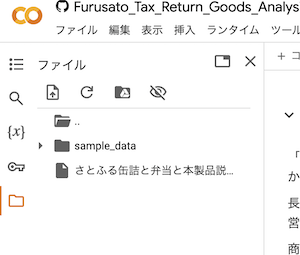

## 分析準備

In [ ]:
!pip install openai
!apt-get -y install fonts-ipafont-gothic
!pip install japanize-matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-ipafont-gothic is already the newest version (00303-21ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import re
import pandas as pd
from bs4 import BeautifulSoup
from google.colab import userdata
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib
import time


## テキストデータの前処理

In [ ]:
def clean_text(text):
    # 特殊文字や句読点を削除
    # text = re.sub(r"[^\w\s]", " ", text)
    # 単一文字を削除
    # text = re.sub(r"\b[a-zA-Z]\b", " ", text)
    # HTMLタグを削除
    text = re.sub(r"<[^>]*>", " ", text)
    # テキストを小文字化
    # text = text.lower()
    # 余分な空白を削除
    text = re.sub(r"\s+", " ", text)
    # 先頭と末尾の空白を削除
    text = text.strip()
    # 全角スペースを削除
    #text = re.sub(r'\u3000', '', text)
    # 特定のパターンを置換
    #text = re.sub(r"^\('(.+?)',\)$", r'\1', text)
    return text

In [ ]:
# ファイルを読み込む
with open('さとふる缶詰と弁当と本製品説明書き.txt', 'r', encoding='shift_jis') as file:
    content = file.read()

# BeautifulSoupを使ってHTMLを解析
soup = BeautifulSoup(content, 'html.parser')

# データを格納するリストを初期化
data = []

# <H1>と<H2>タグを順に処理
for h1_tag in soup.find_all('h1'):
    category = h1_tag.text.strip()
    h2_tags = h1_tag.find_next_siblings('h2')
    for h2_tag in h2_tags:
        # <H2>タグが次の<H1>までの間にあるかを確認
        if h2_tag.find_previous_sibling('h1') == h1_tag:
            product_name = h2_tag.text.strip()
            description = h2_tag.find_next_sibling(text=True).strip()
            data.append([category, product_name, clean_text(description)])

# データフレームに変換
df = pd.DataFrame(data, columns=['Category', 'Product Name', 'Description'])

# 結果を表示
df

/tmp/ipython-input-3606855509.py:19: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  description = h2_tag.find_next_sibling(text=True).strip()


,Category,Product Name,Description
0,缶詰,神奈川県産すっぽん満足セット1,神奈川県産丹沢の水で育てた国産すっぽんをぜひ味わってください。
1,缶詰,サラダチキン 缶詰 24缶セット2,鶏むね肉を煮た缶詰で、ツナ缶の代わりとしても使えます。 前処理工程で加熱していないため、やわ...
2,缶詰,冷たい肉そば(缶詰乾麺9人分) 3,冬でもつったい(冷たい)「かほく冷たい肉そば」、山形県河北町発祥のソウルフードをご家庭で簡単...
3,缶詰,徳重ばあちゃんが受け継いだ「鶯宿梅」の梅肉エキス 4,土づくりからこだわった栽培期間中農薬不使用・自家栽培の在来品種「鶯宿梅」の青梅の青汁だけ、信...
4,缶詰,サラダチキン缶詰(72缶) 5,便利な使い切りサイズで、柔らかく食べやすいサラダチキンです。 サラダやパスタはもちろん、炊き...
...,...,...,...
112,弁当,いいとこ鶏 J11,もち米入りの味付けご飯に刻みのりを敷き 岡山県産の備中森林鶏を色々な味のバリエーションでトッ...
113,弁当,鶏めし弁当 J12,茶飯、鶏そぼろ、海苔、鶏の照り焼き、コールドチキン、赤こんにゃく、舞茸入り肉団子、栗甘露煮、...
114,弁当,じゅうじゅう亭 J13,
115,弁当,suica弁当J20,


## Geminiによる埋込み

In [ ]:
import os
import pandas as pd
from bs4 import BeautifulSoup
import google.generativeai as genai
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
GEMINI_API_KEY=userdata.get('GEMINI_API_KEY')

In [ ]:
genai.configure(api_key=GEMINI_API_KEY)

### text-embedding-004モデルによる埋込み

Gemini の生成モデルを使ってテキストを英語に翻訳する関数

In [ ]:
def translate_to_english(text):
    model = genai.GenerativeModel("gemini-1.5-pro")
    prompt = f"Translate the following text into English:\n\n{text}"

    try:
        response = model.generate_content(prompt)
        time.sleep(10)  # APIの連続呼び出し対策
        return response.text.strip()
    except Exception as e:
        print(f"Translation error for text: {text}\n{e}")
        return None

text-embedding-004（非多言語モデル） を使ってテキストの埋め込みを取得する関数

In [ ]:
def get_embedding(text):
    try:
        result = genai.embed_content(
            model="models/text-embedding-004",
            content=text
        )
        # API連続呼び出し対策として10秒待機
        time.sleep(10)
        return result['embedding']
    except Exception as e:
        print(f"Error for text: {text}\n{e}")
        return None

テキストをまず英語に翻訳し、翻訳結果を使って埋め込みを取得する関数

In [ ]:
def get_embedding_with_translation(text):
    english_text = translate_to_english(text)
    if english_text is None:
        return None
    print(f"Translated text: {english_text}")
    embedding = get_embedding(english_text)
    return embedding

In [ ]:
# Embedding を作成
embeddings = []
successful_indices = []

for i, description in enumerate(df['Description']):
    try:
        # print(i, description)
        embedding = get_embedding_with_translation(description)
        embeddings.append(embedding)
        successful_indices.append(i)
        time.sleep(1)
    except Exception as e:
        print(f"Embedding failed for index {i}: {e}")

# 成功した行だけをデータフレームに残す
df = df.iloc[successful_indices].reset_index(drop=True)
df["embedding"] = embeddings
embeddings_array_gemini = np.array(df["embedding"].tolist())

Translation error for text: 神奈川県産丹沢の水で育てた国産すっぽんをぜひ味わってください。
404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.


Translation error for text: 鶏むね肉を煮た缶詰で、ツナ缶の代わりとしても使えます。 前処理工程で加熱していないため、やわらかく食べ易いです。 サラダや麺類などの素材として大変便利です。
404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
Translation error for text: 冬でもつったい(冷たい)「かほく冷たい肉そば」、山形県河北町発祥のソウルフードをご家庭で簡単に召し上がっていただけます
('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))


Translation error for text: 土づくりからこだわった栽培期間中農薬不使用・自家栽培の在来品種「鶯宿梅」の青梅の青汁だけ、信楽の特注土鍋で7〜8日間じっくりと煮詰め、箸ですくえるほど粘度がとても高い、固く煮詰めた梅のエキスです。 祖母の祖父から、手をとって教え込まれた製法を今でもしっかりと守り、先祖から伝承されてきた知恵の逸品です。 口に含むと、酸っぱさが広がりますが、後味がさっぱりします。 ミネラル成分の含有量の高さが特徴で、口の中で酸っぱさの中に甘みを感じさせてくれます。
404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.


Translation error for text: 便利な使い切りサイズで、柔らかく食べやすいサラダチキンです。 サラダやパスタはもちろん、炊き込みご飯など、アイデア次第で和洋中どんなお料理にも活躍します
404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
Translation error for text: ◆ウインナー・ベーコンスライス・和風ハム・コンビーフのセット!◆ 地元企業「日東ベスト株式会社」が自信を持ってお届けする大満足セットです。 ◆ パリッといい音を奏でるジューシーウインナー! ◆ 噛んだ瞬間のパリッという音!そしてあふれるジューシー感!!ちょっと長めで食べごたえがあるウインナーとベーコンスライスは朝食に最適です。 ◆ いつでもお手軽に楽しめる! ◆ 噛めば噛むほど牛肉本来の旨味と風味が味わえる日本人の味覚に合わせたコンビーフは常温保存が可能です。いつでもお手軽にコンビーフが味わえます。和風ハムもリピート必至のおいしさです。
('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


Translation error for text: 三大珍味と評されるキャビア。独自の製法・貯蔵、絶妙の塩加減のキャビアをご堪能ください。缶詰にはつくば特産の「福来みかん」のパウダーを配合しています。ご当地グルメをお楽しみください。
404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.


...

Translation error for text: 発売は明治32年、百余年を越えた鎌倉ハムを使用した大船軒の伝統の商品です。 ボンレスハムサンドとチーズサンドの2種類の味を楽しむことができます。
404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
Translation error for text: ビジネスマンのための本格的なおつまみ弁当、夕刊フジとＮＲＥ（日本レストランエンタプライズ）が共同開発した「夕刊フジ特選おつまみ弁当」がさらに進化した姿で登場！ビールのプルトップを空けるのが楽しくなる。 ぜひ、しみじみと幸せを味わってほしい
('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


Translation error for text: 昭和39年の発売のロングセラー商品のチキン弁当。 鶏の唐揚げと、トマト風味ライスの組合わせで、お子さまから大人のかたまでお楽しみいただける駅弁です
404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
Translation error for text: 御飯は「深川めし」、「飛騨牛うま煮ご飯」、「梅ちりめんご飯」としました。煮物の炊き方は、濃い口醤油を使った関東風、薄口醤油を使った関西風とし、また、八丁味噌の味で東海を表現してみました。 東海道の味わいの旅をお楽しみください。
('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


Translation error for text: もち米入りの味付けご飯に刻みのりを敷き 岡山県産の備中森林鶏を色々な味のバリエーションでトッピングしました もも肉は塩だれと照り焼きに、むね肉は蒸し鶏と唐揚げに仕上げました シンプルですが、色々な味が楽しめる、鶏好きにはたまらない駅弁です
404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
Translation error for text: 茶飯、鶏そぼろ、海苔、鶏の照り焼き、コールドチキン、赤こんにゃく、舞茸入り肉団子、栗甘露煮、 かりかり梅、わさび風味野沢菜漬け お米は醤油味で炊いた香りの良い御飯になっています。 鶏肉を自社独自の様々な調理法で味付けしてあります。 鶏そぼろは鶏肉の独特の臭みを抜いて、醤油、みりん等で炒り、さっぱりした 味付けにしてあります。 おいしい状態で召し上がって頂けるように、容器は木の折り箱を使っております。 九州出身の先代主人が考案したもので、鶏肉のおいしさを十分に引き出しています。 販売したのが昭和9年、以来根強い人気で今日に至っていますが、 昔ながらの味を大切に守っているお弁当です。
('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


Translation error for text: 
404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
Translation error for text: 
('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


Translation error for text: お礼品の内容・特徴 昭和36年創業の日本料理成田家が、創業当時のレシピの割下を使って仕上げたどこか懐かしい味の鶏のすき焼きの缶詰です。厳選した地場産野菜を使用しています。 すき焼きとしてはもちろん、少しアレンジすれば洋風料理としてもお召し上がりいただけます。 本製品は、日本料理成田家と追手門学院大学ベンチャービジネス研究会と経営学部の学生有志の連携で開発されました。 お召し上がり方 中身を耐熱性の容器に移し、軽くラップをかけ電子レンジで温めていただくか、中身をお鍋に移し温めてお召し上がりください。 簡単アレンジレシピ 本品を使った、簡単でおいしいお料理の例をご紹介します。 鶏肉うどん:鍋でうどんをさっと茹で、そこに本品を汁ごと入れて炊く。 グラタン風すき焼き:グラタン皿に本品を移しかえ、ホワイトソースととろけるチーズをのせてオーブンに。 すき焼き丼:丼鍋に本品を入れて汁ごと煮立て、溶き卵をかきいれる。ご飯にかけて召し上がれ。 内容量/製造地 鶏のすき焼き 290g×6缶 製造地:兵庫県たつの市 原材料 鶏もも肉、豆腐、割下(出汁〈鰹節、昆布〉、醤油、みりん、上白糖)、玉ねぎ、えのき茸、椎茸、白ねぎ(一部に小麦・大豆を含む) 賞味期限 製造より3年。非常時用の備蓄としてもお使いいただけます。 注意事項/その他 使い残しが出た場合は、他の容器に移し冷蔵庫に入れ、お早めにお召し上がりください。 画像はイメージです。
404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.


768次元のベクトルとして表現される

### 可視化

In [ ]:
# フォントの設定
plt.rcParams['font.family'] = 'IPAPGothic'
japanize_matplotlib.japanize()

#### 主成分分析

In [ ]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings_array_gemini)

df["PCA1"] = reduced[:, 0]
df["PCA2"] = reduced[:, 1]

plt.figure(figsize=(10, 8))
plt.scatter(df["PCA1"], df["PCA2"], alpha=0.7)
for i, row in df.iterrows():
    plt.annotate(row["Product Name"], (row["PCA1"], row["PCA2"]), fontsize=8)
plt.title("Gemini API Embedding PCA 可視化")
plt.xlabel("主成分 1")
plt.ylabel("主成分 2")
plt.grid(True)
plt.show()

ValueError: Expected 2D array, got 1D array instead:
array=[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [ ]:
# Ward法による階層型クラスタリング
linkage_matrix = linkage(embeddings_array_gemini, method='ward')
clusters = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward').fit_predict(embeddings_array_gemini)

# クラスタリング結果をデータフレームに追加
df['Cluster'] = clusters

# デンドログラムをプロット
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=df['Product Name'].values, leaf_rotation=90)
plt.title('Dendrogram (Hierarchical Clustering using Ward method)')
plt.xlabel('Product Name')
plt.ylabel('Distance')
plt.show()


## ChatGPTによる埋込み

In [ ]:
OPENAI_API_KEY=userdata.get('OPENAI_API_KEY')

In [ ]:
from openai import OpenAI

client = openai.OpenAI(api_key=OPENAI_API_KEY)


def get_embedding(text, model="text-embedding-3-small", dim=None):
    text = text.replace("\n", " ")
    if dim is None:
        return client.embeddings.create(input=[text], model=model).data[0].embedding
    else:
        return (
            client.embeddings.create(input=[text], model=model, dimensions=dim)
            .data[0]
            .embedding
        )

In [ ]:
# Embeddingを作成
embeddings = []
successful_indices = []

for i, description in enumerate(df['Description']):
  try:
    embedding = get_embedding(
        text=description,
        model="text-embedding-3-small"
    )
    embeddings.append(embedding)
    successful_indices.append(i)
  except Exception as e:
    print(f"Embedding failed for index {i}")

# 成功した行だけをデータフレームに残す
df = df.iloc[successful_indices].reset_index(drop=True)

1536次元のベクトルとして表現される

In [ ]:
embeddings_array = np.array(embeddings)
embeddings_array.shape

### 可視化

In [ ]:
# フォントの設定
plt.rcParams['font.family'] = 'IPAPGothic'
japanize_matplotlib.japanize()

### クラスタ分析

In [ ]:
# Ward法による階層型クラスタリング
linkage_matrix = linkage(embeddings_array, method='ward')
clusters = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward').fit_predict(embeddings_array)

# クラスタリング結果をデータフレームに追加
df['Cluster'] = clusters

# デンドログラムをプロット
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=df['Product Name'].values, leaf_rotation=90)
plt.title('Dendrogram (Hierarchical Clustering using Ward method)')
plt.xlabel('Product Name')
plt.ylabel('Distance')
plt.show()


### t-SNEによる散布図のプロット

In [ ]:
# t-SNEで次元削減
embeddings_array = np.array(embeddings)
tsne = TSNE(n_components=2)
tsne_results = tsne.fit_transform(embeddings_array)

# データフレームにt-SNEの結果を追加
df['tsne-2d-one'] = tsne_results[:, 0]
df['tsne-2d-two'] = tsne_results[:, 1]


In [ ]:
# 色をカテゴリごとに設定
unique_categories = df['Category'].unique()
palette = sns.color_palette("hsv", len(unique_categories))
category_color_mapping = {category: palette[i] for i, category in enumerate(unique_categories)}

# 散布図をプロット
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="Category",
    palette=category_color_mapping,
    data=df,
    legend="full",
    alpha=0.8
)

# 各ポイントに商品名を表示
for i, product_name in enumerate(df['Product Name']):
    plt.text(tsne_results[i, 0], tsne_results[i, 1], product_name, fontsize=8)

plt.title('t-SNE visualization of product descriptions by category')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.grid(True)
plt.show()

## BERT（おまけ）

日本語pre-trained model（東北大学）を使用

In [ ]:
!pip install transformers
!pip install torch
!pip install fugashi
!pip install ipadic

In [ ]:
import pandas as pd
from transformers import BertModel, BertJapaneseTokenizer
import torch
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib

In [ ]:
#モデルとトークナイザの設定
model_name = "cl-tohoku/bert-base-japanese-whole-word-masking"#単語

tokenizer = BertJapaneseTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

In [ ]:
# Embeddingを作成
embeddings = []
successful_indices = []

for i, description in enumerate(df['Description']):
  try:
    inputs = tokenizer(description, return_tensors="pt", max_length=512, truncation=True, padding="max_length")
    with torch.no_grad():
        outputs = model(**inputs)#モデルにトークナイズしたテキストを入力
    cls_embedding = outputs.last_hidden_state[:, 0, :].numpy()#
    embeddings.append(cls_embedding[0])#リストに追加
    successful_indices.append(i)
  except Exception as e:
    print(f"Embedding failed for index {i}")

# 成功した行だけをデータフレームに残す
df = df.iloc[successful_indices].reset_index(drop=True)

In [ ]:
embeddings_array = np.array(embeddings)
embeddings_array.shape

In [ ]:
# Ward法による階層型クラスタリング
linkage_matrix = linkage(embeddings_array, method='ward')
clusters = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward').fit_predict(embeddings_array)

# クラスタリング結果をデータフレームに追加
df['Cluster'] = clusters

# デンドログラムをプロット
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=df['Product Name'].values, leaf_rotation=90)
plt.title('Dendrogram (Hierarchical Clustering using Ward method)')
plt.xlabel('Product Name')
plt.ylabel('Distance')
plt.show()